# 🍽️ Seeding Review Classifier
Detect fake/seeded restaurant reviews vs genuine ones using multi-feature ML + PhoBERT fine-tuning.

**Labels:**
- `0` → Genuine review
- `1` → Seeding (fake/paid) review

**Dataset:** Vietnamese restaurant Google Maps reviews with pre-labeled `auto_label` column.

---
## Pipeline overview
1. EDA & data inspection
2. Feature engineering (text + reviewer behavioral features)
3. Baseline ML models (TF-IDF + Random Forest / XGBoost)
4. PhoBERT fine-tuning for Vietnamese text understanding
5. Evaluation & confusion matrix
6. Inference on new reviews

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Install dependencies

In [2]:
!pip install -q transformers datasets underthesea scikit-learn imbalanced-learn xgboost seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.2 MB/s eta 0:00:00


## 1. Upload & load data

In [3]:
from google.colab import files
uploaded = files.upload()  # Upload your reviews.csv here

Saving reviews.csv to reviews.csv


In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('reviews.csv')

# Drop exact duplicate rows (same review scraped twice)
df = df.drop_duplicates(subset=['text', 'reviewer_name', 'date', 'place_name'])
df = df.reset_index(drop=True)

print(f'Shape after dedup: {df.shape}')
print(df.dtypes)
df.head(3)

Shape after dedup: (161, 11)
place_name               object
text                     object
rating                    int64
reviewer_name            object
reviewer_review_count     int64
reviewer_photo_count      int64
date                     object
source_url               object
scraped_at               object
auto_label                int64
needs_manual_check        int64
dtype: object


,place_name,text,rating,reviewer_name,reviewer_review_count,reviewer_photo_count,date,source_url,scraped_at,auto_label,needs_manual_check
0,Hải sản Hùng Trường Sa,Mình không ăn tại cửa hàng mà mua về. Tôm mua ...,5,Duc Nguyen,375,533,5 months ago,https://www.google.com/maps/place/H%E1%BA%A3i+...,2026-06-04T12:19:55.360561,0,0
1,Hải sản Hùng Trường Sa,Đồ ăn ngon giá cả okay nhưng nhân viên chưa bi...,4,quach hienthu2501,29,37,3 months ago,https://www.google.com/maps/place/H%E1%BA%A3i+...,2026-06-04T12:19:55.704953,0,0
2,Hải sản Hùng Trường Sa,Đồ ăn rất ngon tuy nhiên cũng hơi đắt.,5,Trí Nguyễn,17,34,3 months ago,https://www.google.com/maps/place/H%E1%BA%A3i+...,2026-06-04T12:19:56.529211,0,0


## 2. Exploratory Data Analysis (EDA)

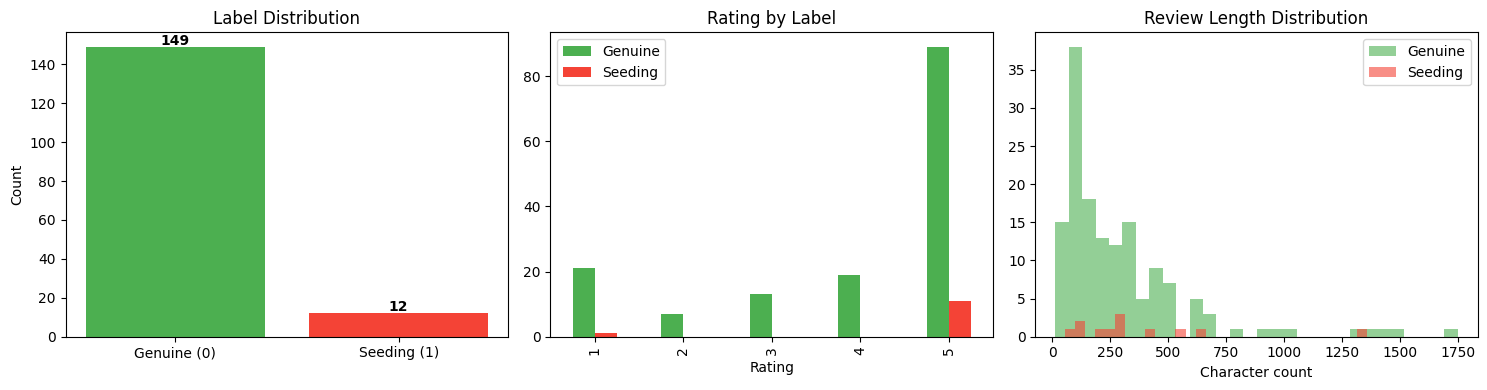


Class balance (%):
auto_label
0    92.5
1     7.5
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Label distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_counts = df['auto_label'].value_counts()
axes[0].bar(['Genuine (0)', 'Seeding (1)'], label_counts.values, color=['#4CAF50','#F44336'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# ── Rating distribution per label ──────────────────────────────
df.groupby(['auto_label', 'rating']).size().unstack(fill_value=0).T.plot(
    kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], legend=True
)
axes[1].set_title('Rating by Label')
axes[1].set_xlabel('Rating')
axes[1].legend(['Genuine', 'Seeding'])

# ── Review length distribution ─────────────────────────────────
df['text_len'] = df['text'].astype(str).str.len()
for label, color, name in [(0,'#4CAF50','Genuine'), (1,'#F44336','Seeding')]:
    axes[2].hist(df[df['auto_label']==label]['text_len'], bins=30,
                 alpha=0.6, color=color, label=name)
axes[2].set_title('Review Length Distribution')
axes[2].set_xlabel('Character count')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\nClass balance (%):')
print((df['auto_label'].value_counts(normalize=True)*100).round(1))

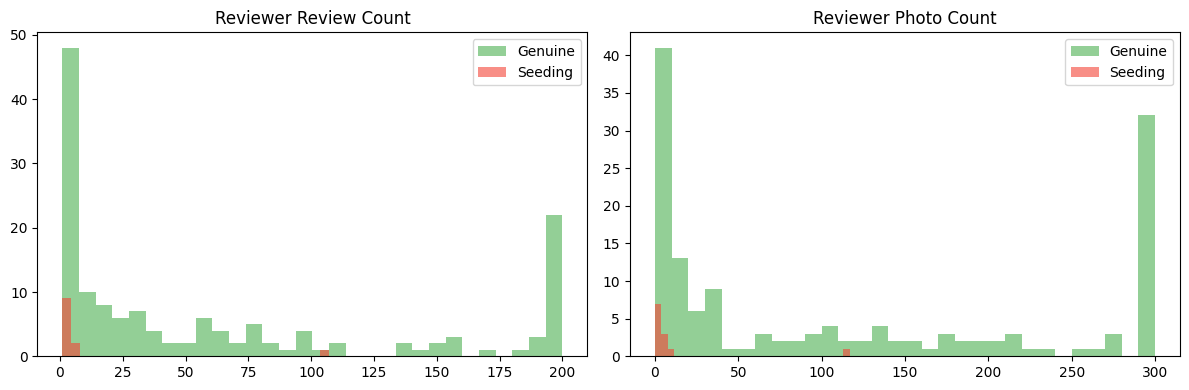

Mean reviewer stats by label:
            reviewer_review_count  reviewer_photo_count  rating  text_len
auto_label                                                               
0                            86.2                 185.1     4.0     297.8
1                            10.6                  12.8     4.7     387.6


In [6]:
# ── Reviewer behavior analysis ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, name in [(0,'#4CAF50','Genuine'), (1,'#F44336','Seeding')]:
    subset = df[df['auto_label']==label]
    axes[0].hist(subset['reviewer_review_count'].clip(0, 200), bins=30,
                 alpha=0.6, color=color, label=name)
    axes[1].hist(subset['reviewer_photo_count'].clip(0, 300), bins=30,
                 alpha=0.6, color=color, label=name)

axes[0].set_title('Reviewer Review Count')
axes[0].legend()
axes[1].set_title('Reviewer Photo Count')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Mean reviewer stats by label:')
print(df.groupby('auto_label')[['reviewer_review_count','reviewer_photo_count','rating','text_len']].mean().round(1))

## 3. Feature Engineering

In [7]:
import re

def build_features(df):
    df = df.copy()
    text = df['text'].astype(str)

    # ── Text features ─────────────────────────────────────────────
    df['text_len']         = text.str.len()
    df['word_count']       = text.str.split().str.len()
    df['exclamation_count']= text.str.count('!')
    df['emoji_count']      = text.apply(lambda t: len(re.findall(
        r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\u2600-\u26FF]', t)))
    df['caps_ratio']       = text.apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t),1))
    df['has_price']        = text.str.contains(r'\d+[kK]|đồng|vnd|giá', case=False).astype(int)
    df['has_recommend']    = text.str.contains(
        r'recommend|gợi ý|giới thiệu|nên thử|must|highly', case=False).astype(int)
    df['has_negative']     = text.str.contains(
        r'tệ|dở|chán|thất vọng|không ngon|bad|terrible|worst|awful', case=False).astype(int)
    df['unique_char_ratio']= text.apply(lambda t: len(set(t)) / max(len(t),1))
    df['avg_word_len']     = text.apply(
        lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)
    # Repetition: ratio of unique words to total words (low = repetitive)
    df['vocab_richness']   = text.apply(
        lambda t: len(set(t.lower().split())) / max(len(t.split()),1))

    # ── Reviewer behavioral features ─────────────────────────────
    df['low_review_count'] = (df['reviewer_review_count'] < 5).astype(int)
    df['low_photo_count']  = (df['reviewer_photo_count'] < 5).astype(int)
    df['new_reviewer']     = ((df['reviewer_review_count'] < 5) &
                               (df['reviewer_photo_count'] < 5)).astype(int)
    # Perfect rating from new reviewer (classic seeding signal)
    df['perfect_from_new'] = ((df['rating'] == 5) & (df['new_reviewer'] == 1)).astype(int)
    df['rating_5']         = (df['rating'] == 5).astype(int)

    return df

df = build_features(df)

FEATURE_COLS = [
    'text_len', 'word_count', 'exclamation_count', 'emoji_count',
    'caps_ratio', 'has_price', 'has_recommend', 'has_negative',
    'unique_char_ratio', 'avg_word_len', 'vocab_richness',
    'reviewer_review_count', 'reviewer_photo_count',
    'low_review_count', 'low_photo_count', 'new_reviewer',
    'perfect_from_new', 'rating', 'rating_5'
]

print('Feature columns:', len(FEATURE_COLS))
df[FEATURE_COLS + ['auto_label']].describe().T.round(2)

Feature columns: 19


,count,mean,std,min,25%,50%,75%,max
text_len,161.0,304.52,300.18,14.00,109.00,225.00,367.00,1749.00
word_count,161.0,66.37,64.74,4.00,25.00,47.00,83.00,378.00
exclamation_count,161.0,0.35,1.12,0.00,0.00,0.00,0.00,11.00
emoji_count,161.0,0.07,0.29,0.00,0.00,0.00,0.00,2.00
caps_ratio,161.0,0.02,0.01,0.00,0.01,0.02,0.03,0.10
has_price,161.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
has_recommend,161.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
has_negative,161.0,0.13,0.34,0.00,0.00,0.00,0.00,1.00
unique_char_ratio,161.0,0.26,0.13,0.03,0.16,0.23,0.34,0.68
avg_word_len,161.0,3.57,0.57,2.71,3.25,3.41,3.64,5.78


## 4. Baseline: TF-IDF + ML Models
We combine handcrafted features with TF-IDF bag-of-words from the review text.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# ── Prepare X, y ─────────────────────────────────────────────────
X_text = df['text'].astype(str)
X_meta = df[FEATURE_COLS].fillna(0)
y      = df['auto_label']

# Train/test split — stratified to preserve class ratio
X_text_tr, X_text_te, X_meta_tr, X_meta_te, y_tr, y_te = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# ── TF-IDF on text ───────────────────────────────────────────────
tfidf = TfidfVectorizer(
    analyzer='char_wb',   # char n-grams work better for Vietnamese
    ngram_range=(2, 4),
    max_features=5000,
    sublinear_tf=True
)
X_tfidf_tr = tfidf.fit_transform(X_text_tr)
X_tfidf_te = tfidf.transform(X_text_te)

# ── Combine TF-IDF + metadata ─────────────────────────────────────
X_tr = hstack([X_tfidf_tr, csr_matrix(X_meta_tr.values)])
X_te = hstack([X_tfidf_te, csr_matrix(X_meta_te.values)])

# ── Handle class imbalance with SMOTE ────────────────────────────
smote = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)
print(f'After SMOTE — train size: {X_tr_bal.shape}, class counts: {np.bincount(y_tr_bal)}')
print(f'Test size: {X_te.shape}')

After SMOTE — train size: (236, 5019), class counts: [118 118]
Test size: (33, 5019)


In [9]:
# ── Train and compare multiple models ─────────────────────────────

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                              use_label_encoder=False, eval_metric='logloss',
                                              random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_tr_bal, y_tr_bal)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    auc  = roc_auc_score(y_te, y_proba)
    f1   = f1_score(y_te, y_pred)
    results.append({'Model': name, 'AUC-ROC': round(auc,4), 'F1 (seeding)': round(f1,4)})
    print(f'\n── {name} ──')
    print(classification_report(y_te, y_pred, target_names=['Genuine','Seeding']))

print('\n=== Summary ===')
pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)


── Logistic Regression ──
              precision    recall  f1-score   support

     Genuine       1.00      0.87      0.93        31
     Seeding       0.33      1.00      0.50         2

    accuracy                           0.88        33
   macro avg       0.67      0.94      0.72        33
weighted avg       0.96      0.88      0.90        33


── Random Forest ──
              precision    recall  f1-score   support

     Genuine       0.94      1.00      0.97        31
     Seeding       0.00      0.00      0.00         2

    accuracy                           0.94        33
   macro avg       0.47      0.50      0.48        33
weighted avg       0.88      0.94      0.91        33


── XGBoost ──
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.98        31
     Seeding       0.67      1.00      0.80         2

    accuracy                           0.97        33
   macro avg       0.83      0.98      0.89        33
weighted av

,Model,AUC-ROC,F1 (seeding)
0,Logistic Regression,0.9839,0.5000
2,XGBoost,0.9839,0.8000
3,SVM (RBF),0.9516,0.2222
1,Random Forest,0.8710,0.0000


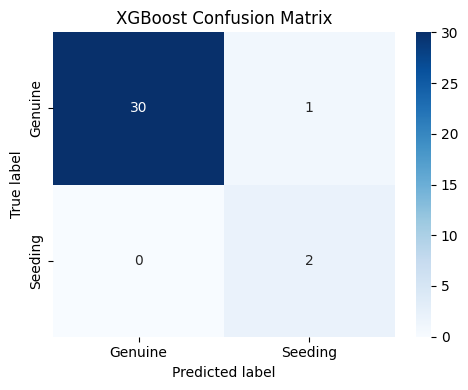

In [10]:
# ── Confusion matrix for best model (XGBoost) ────────────────────
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_te)

cm = confusion_matrix(y_te, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Seeding'],
            yticklabels=['Genuine','Seeding'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

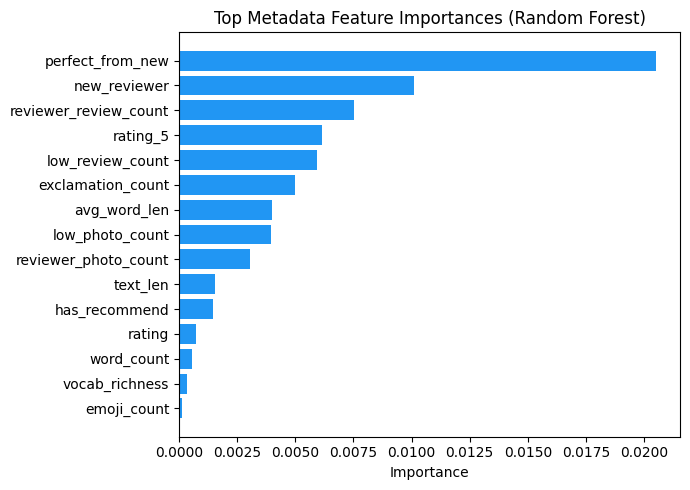

In [11]:
# ── Feature importance from Random Forest ─────────────────────────
rf = models['Random Forest']
meta_importances = rf.feature_importances_[-len(FEATURE_COLS):]
feat_imp = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': meta_importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(7,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3')
plt.title('Top Metadata Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. PhoBERT Fine-tuning (Deep Learning)
PhoBERT is a pre-trained BERT model for Vietnamese. Fine-tuning it on our labeled data gives much stronger text understanding.

> ⚡ **Recommended**: Use Colab GPU (Runtime → Change runtime type → T4 GPU)

In [12]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import classification_report, roc_auc_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cpu':
    print('⚠️  No GPU detected. PhoBERT training will be slow. '
          'Go to Runtime → Change runtime type → GPU.')

Using device: cuda


In [13]:
MODEL_NAME = 'vinai/phobert-base-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded:', MODEL_NAME)

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Tokenizer loaded: vinai/phobert-base-v2


In [14]:
MAX_LEN   = 256   # PhoBERT max = 256 for phobert-base
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Split (reuse same indices from baseline) ─────────────────────
# Rebuild using the deduplicated df
from sklearn.model_selection import train_test_split as tts
idx_tr, idx_te = tts(df.index, test_size=0.2, random_state=42, stratify=df['auto_label'])

train_ds = ReviewDataset(df.loc[idx_tr,'text'], df.loc[idx_tr,'auto_label'], tokenizer, MAX_LEN)
test_ds  = ReviewDataset(df.loc[idx_te,'text'], df.loc[idx_te,'auto_label'], tokenizer, MAX_LEN)

# Class weights for imbalance
neg, pos = np.bincount(df.loc[idx_tr,'auto_label'])
class_weight = torch.tensor([1.0, neg/pos], dtype=torch.float).to(DEVICE)
print(f'Class weights — Genuine: 1.0, Seeding: {neg/pos:.1f}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_ds)} | Test: {len(test_ds)}')

Class weights — Genuine: 1.0, Seeding: 11.8
Train: 128 | Test: 33


In [15]:
# ── Load PhoBERT model ────────────────────────────────────────────
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss(weight=class_weight)

print(f'Model parameters: {sum(p.numel() for p in model_bert.parameters()):,}')

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Model parameters: 134,999,810


In [16]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds  = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total  += len(labels)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_probs, all_labels = 0, [], [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)
        total_loss += loss.item()

        probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return (total_loss / len(loader),
            np.array(all_preds),
            np.array(all_probs),
            np.array(all_labels))


print('Training PhoBERT...')
best_f1, history = 0, []

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model_bert, train_loader, optimizer, scheduler, loss_fn, DEVICE)
    te_loss, te_preds, te_probs, te_labels = evaluate(model_bert, test_loader, loss_fn, DEVICE)

    f1  = f1_score(te_labels, te_preds)
    auc = roc_auc_score(te_labels, te_probs)
    history.append({'epoch': epoch, 'tr_loss': tr_loss, 'te_loss': te_loss,
                    'f1': f1, 'auc': auc})

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  '
          f'F1={f1:.4f}  AUC={auc:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_bert.state_dict(), 'phobert_seeding_best.pt')
        print(f'  ✅ Best model saved (F1={f1:.4f})')

Training PhoBERT...
Epoch 1/5  train_loss=0.6957  test_loss=0.6532  F1=0.2222  AUC=0.5968
  ✅ Best model saved (F1=0.2222)
Epoch 2/5  train_loss=0.6335  test_loss=0.5923  F1=0.2857  AUC=0.5645
  ✅ Best model saved (F1=0.2857)
Epoch 3/5  train_loss=0.5698  test_loss=0.5639  F1=0.2500  AUC=0.5806
Epoch 4/5  train_loss=0.5086  test_loss=0.5415  F1=0.2500  AUC=0.5806
Epoch 5/5  train_loss=0.5012  test_loss=0.5321  F1=0.2500  AUC=0.5806


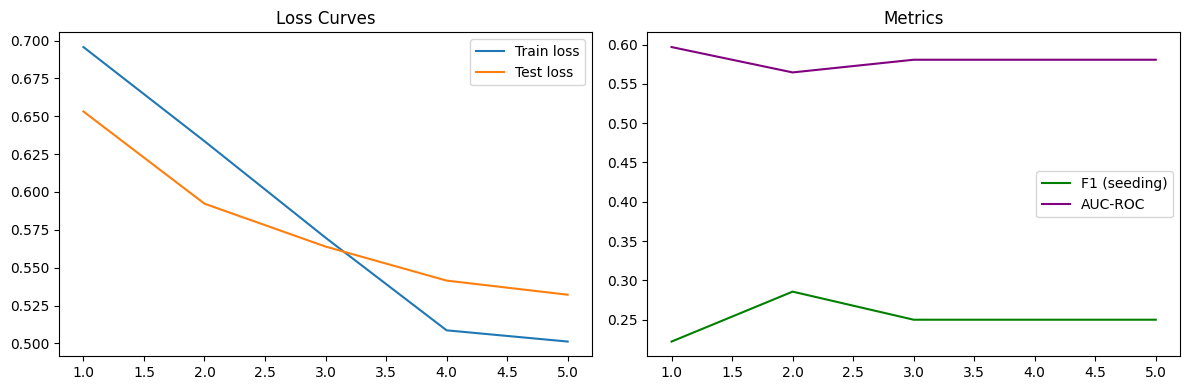

In [17]:
# ── Training curves ───────────────────────────────────────────────
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['te_loss'], label='Test loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['f1'],  label='F1 (seeding)', color='green')
axes[1].plot(hist_df['epoch'], hist_df['auc'], label='AUC-ROC', color='purple')
axes[1].set_title('Metrics')
axes[1].legend()
plt.tight_layout()
plt.show()

=== PhoBERT Final Report ===
              precision    recall  f1-score   support

     Genuine       0.96      0.87      0.92        31
     Seeding       0.20      0.50      0.29         2

    accuracy                           0.85        33
   macro avg       0.58      0.69      0.60        33
weighted avg       0.92      0.85      0.88        33

AUC-ROC: 0.5645


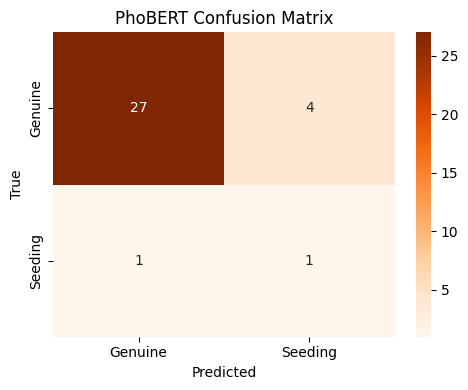

In [18]:
# ── Final evaluation with best checkpoint ────────────────────────
model_bert.load_state_dict(torch.load('phobert_seeding_best.pt', map_location=DEVICE))
_, te_preds, te_probs, te_labels = evaluate(model_bert, test_loader, loss_fn, DEVICE)

print('=== PhoBERT Final Report ===')
print(classification_report(te_labels, te_preds, target_names=['Genuine','Seeding']))
print(f'AUC-ROC: {roc_auc_score(te_labels, te_probs):.4f}')

cm = confusion_matrix(te_labels, te_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Genuine','Seeding'],
            yticklabels=['Genuine','Seeding'])
plt.title('PhoBERT Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6. Inference — Predict on New Reviews

In [19]:
@torch.no_grad()
def predict_review(text, reviewer_review_count=10, reviewer_photo_count=10,
                   rating=5, threshold=0.5):
    """
    Predict whether a review is seeding (fake) or genuine.
    Returns dict with label, confidence, and key signals.
    """
    # PhoBERT text score
    model_bert.eval()
    enc = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt').to(DEVICE)
    logits  = model_bert(**enc).logits
    bert_prob = torch.softmax(logits, dim=1)[0,1].item()

    # Rule-based signals
    signals = []
    if reviewer_review_count < 5:  signals.append('new_reviewer')
    if reviewer_photo_count < 5:   signals.append('low_photos')
    if rating == 5 and reviewer_review_count < 5:
        signals.append('perfect_from_new_reviewer')
    text_len = len(text)
    if text_len < 20:              signals.append('very_short_review')

    # Blend: 70% PhoBERT + 30% heuristic
    heuristic_score = min(len(signals) / 3, 1.0)
    final_prob = 0.7 * bert_prob + 0.3 * heuristic_score

    label = 'SEEDING 🚩' if final_prob >= threshold else 'GENUINE ✅'
    return {
        'label':          label,
        'seeding_prob':   round(final_prob, 4),
        'bert_prob':      round(bert_prob, 4),
        'signals':        signals
    }


# ── Test examples ─────────────────────────────────────────────────
test_cases = [
    {
        'text': 'Quán ăn ngon tuyệt vời! Đồ ăn rất ngon, nhân viên nhiệt tình, không gian đẹp. Sẽ quay lại lần sau!',
        'reviewer_review_count': 1, 'reviewer_photo_count': 0, 'rating': 5
    },
    {
        'text': 'Mình đã ăn ở đây nhiều lần. Lần này đồ ăn hơi mặn hơn bình thường, nhưng vẫn chấp nhận được. Giá cả hợp lý.',
        'reviewer_review_count': 89, 'reviewer_photo_count': 212, 'rating': 3
    },
    {
        'text': 'Highly recommend! Best food in the area, amazing service!',
        'reviewer_review_count': 2, 'reviewer_photo_count': 1, 'rating': 5
    },
]

for i, case in enumerate(test_cases, 1):
    result = predict_review(**case)
    print(f'\nReview {i}: "{case["text"][:60]}..."')
    print(f'  → {result["label"]}  (seeding_prob={result["seeding_prob"]})')
    print(f'     bert_prob={result["bert_prob"]}  signals={result["signals"]}')


Review 1: "Quán ăn ngon tuyệt vời! Đồ ăn rất ngon, nhân viên nhiệt tình..."
  → SEEDING 🚩  (seeding_prob=0.5704)
     bert_prob=0.3863  signals=['new_reviewer', 'low_photos', 'perfect_from_new_reviewer']

Review 2: "Mình đã ăn ở đây nhiều lần. Lần này đồ ăn hơi mặn hơn bình t..."
  → GENUINE ✅  (seeding_prob=0.2736)
     bert_prob=0.3909  signals=[]

Review 3: "Highly recommend! Best food in the area, amazing service!..."
  → SEEDING 🚩  (seeding_prob=0.6643)
     bert_prob=0.5204  signals=['new_reviewer', 'low_photos', 'perfect_from_new_reviewer']


## 7. Save & Export

In [20]:
import joblib, os

# Save TF-IDF vectorizer & XGBoost model
joblib.dump(tfidf,   'tfidf_vectorizer.pkl')
joblib.dump(models['XGBoost'], 'xgboost_seeding.pkl')

# Save PhoBERT
model_bert.save_pretrained('phobert_seeding_model')
tokenizer.save_pretrained('phobert_seeding_model')

print('Saved files:')
for f in ['tfidf_vectorizer.pkl', 'xgboost_seeding.pkl',
          'phobert_seeding_best.pt', 'phobert_seeding_model']:
    if os.path.exists(f):
        print(f'  ✅ {f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files:
  ✅ tfidf_vectorizer.pkl
  ✅ xgboost_seeding.pkl
  ✅ phobert_seeding_best.pt
  ✅ phobert_seeding_model


In [21]:
# ── Download all artifacts ────────────────────────────────────────
import shutil
from google.colab import files

shutil.make_archive('seeding_model_artifacts', 'zip', '.', 'phobert_seeding_model')
for fname in ['tfidf_vectorizer.pkl', 'xgboost_seeding.pkl',
              'phobert_seeding_best.pt', 'seeding_model_artifacts.zip']:
    if os.path.exists(fname):
        files.download(fname)
print('Downloads triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered.


---
## 📝 Notes & Tips

### Understanding the two approaches
| Approach | Pros | Cons |
|---|---|---|
| TF-IDF + XGBoost | Fast, interpretable, works with small data | Misses Vietnamese semantics |
| PhoBERT | Understands Vietnamese context deeply | Needs GPU, slower inference |

### Seeding signals used
- **New reviewer** (< 5 reviews ever): Classic sock-puppet pattern
- **Perfect 5-star from new reviewer**: Very strong seeding indicator
- **Short, generic text**: `"Quán ngon!"` with no specifics
- **High exclamation / emoji count**: Overly enthusiastic tone
- **Very high vocabulary richness** OR suspiciously low: Both can signal templated text

### Improving accuracy
- Label more data, especially positive seeding examples (currently only 32 / 320 = 10%)
- Add cross-restaurant same-reviewer detection (same person reviews multiple of your competitors)
- Add temporal features: reviews posted in short bursts
- Try `vinai/phobert-large` for better accuracy at cost of speed

### Threshold tuning
Lower the threshold (e.g. `0.35`) to catch more seeding reviews at the cost of more false positives.
Raise it (e.g. `0.65`) to only flag highly confident cases.